In [1171]:
!pip install streamlit plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 2.8 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.9 MB 3.7 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 5.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 6.3 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 7.7 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 7.2 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 6.3 MB/s  0:00:01


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1172]:
import numpy as np
import pandas as pd 
import seaborn as sns   
import matplotlib.pyplot as plt
import warnings

In [1173]:
warnings.filterwarnings('ignore')  

In [1174]:
df=pd.read_csv("insurance.csv")

In [1175]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#EDA


In [1176]:
df.shape



(1338, 7)

In [1177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [1178]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [1179]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [1180]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [1181]:
numeric_columns=df.select_dtypes(include=np.number).columns.tolist()    

In [1182]:
numeric_columns

['age', 'bmi', 'children', 'charges']

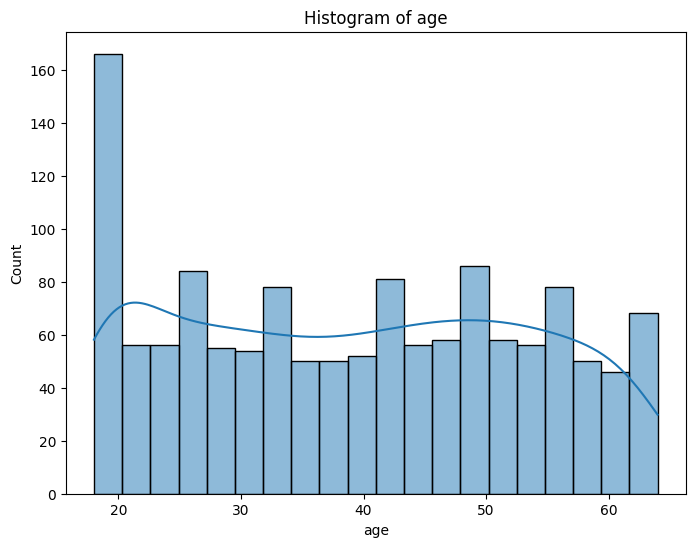

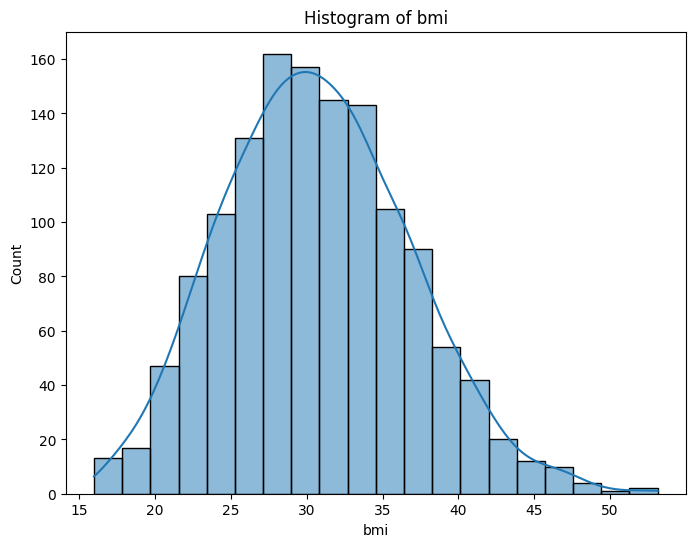

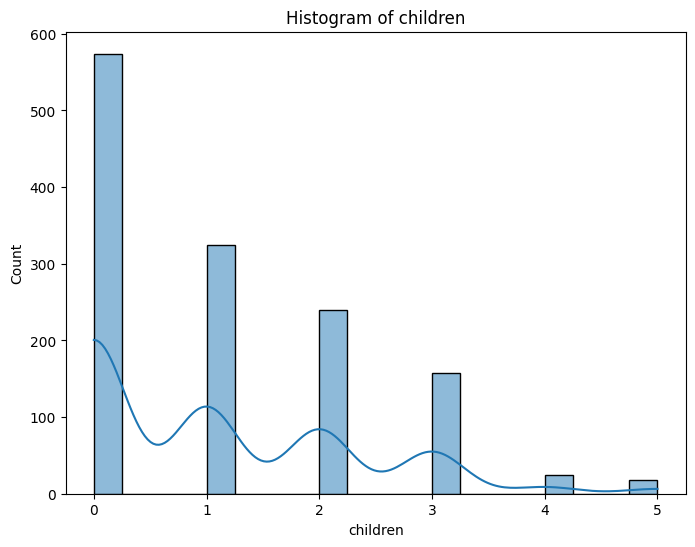

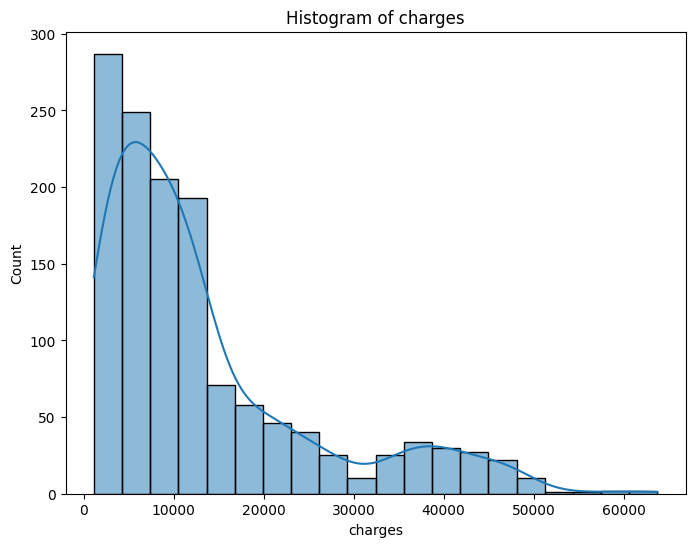

In [1183]:
for col in numeric_columns:
    plt.figure(figsize=(8,6))
    sns.histplot(df[col],kde=True,bins=20)
    plt.title(f'Histogram of {col}')
    plt.show()

<Axes: xlabel='children', ylabel='count'>

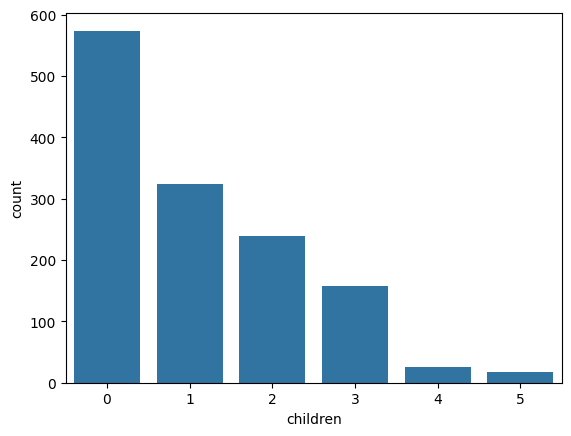

In [1184]:
sns.countplot(x=df['children'])    


<Axes: xlabel='sex', ylabel='count'>

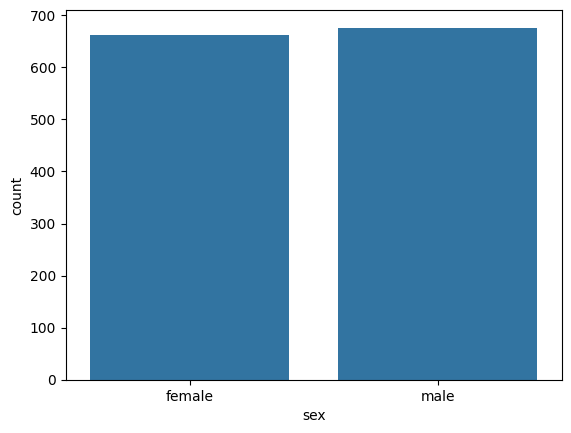

In [1185]:
sns.countplot(x=df['sex'])  

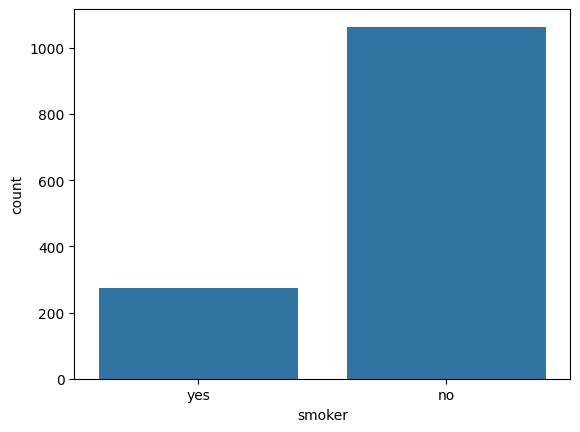

In [1186]:
sns.countplot(x='smoker',data=df)   
plt.show()

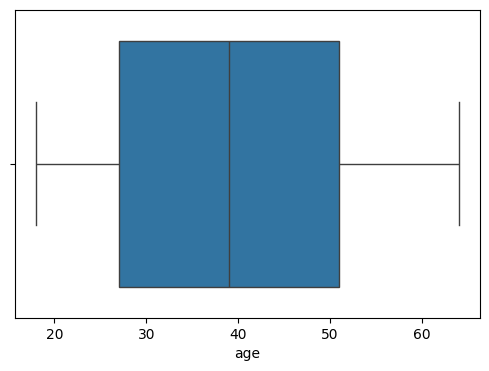

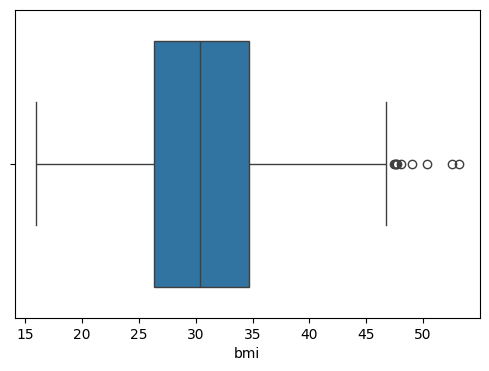

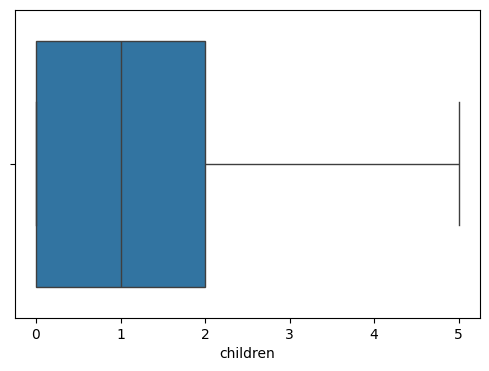

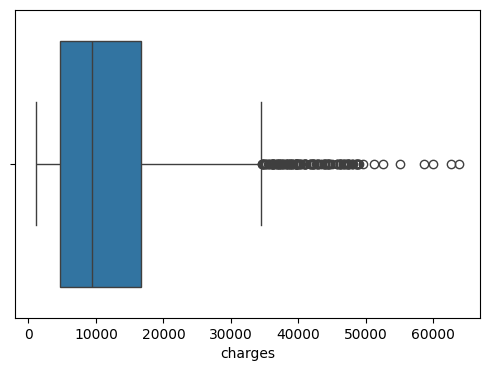

In [1187]:
for col in numeric_columns:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

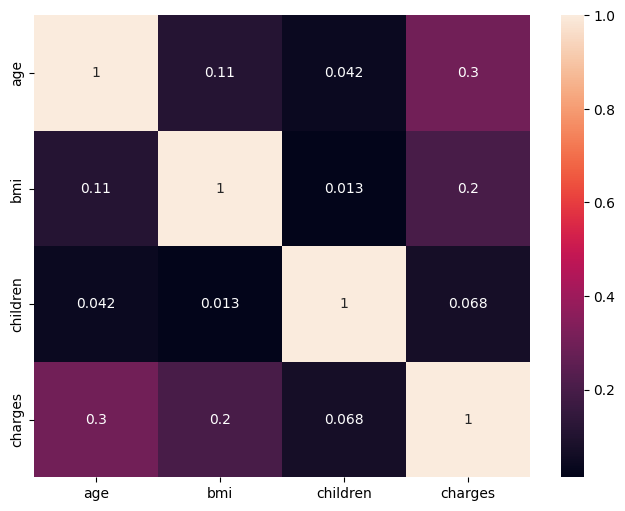

In [1188]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()


#Data cleaning ad pre processing

In [1189]:
df.isnull().sum()   

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [1190]:
df_cleaned=df.copy()

In [1191]:
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [1192]:
df.shape

(1338, 7)

In [1193]:
df.drop_duplicates(inplace=True)

In [1194]:
df.shape

(1337, 7)

In [1195]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [1196]:
df_cleaned['sex'].value_counts()    

sex
male      676
female    662
Name: count, dtype: int64

In [1197]:
df_cleaned['sex']=df_cleaned['sex'].map({"male":0,"female":1})

In [1198]:
df_cleaned.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [1199]:
df_cleaned['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [1200]:
df_cleaned['smoker']=df_cleaned['smoker'].map({"yes":1,"no":0})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [1201]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
},inplace=True)

In [1202]:
df_cleaned.tail()

,age,is_female,bmi,children,is_smoker,region,charges
1333,50,0,30.97,3,0,northwest,10600.5483
1334,18,1,31.92,0,0,northeast,2205.9808
1335,18,1,36.85,0,0,southeast,1629.8335
1336,21,1,25.80,0,0,southwest,2007.9450
1337,61,1,29.07,0,1,northwest,29141.3603


In [1203]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [1204]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=False)

In [1205]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [1206]:
df_cleaned=df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


In [1207]:
df_cleaned.dtypes

age                 int64
is_female           int64
bmi                 int64
children            int64
is_smoker           int64
charges             int64
region_northeast    int64
region_northwest    int64
region_southeast    int64
region_southwest    int64
dtype: object

#Feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

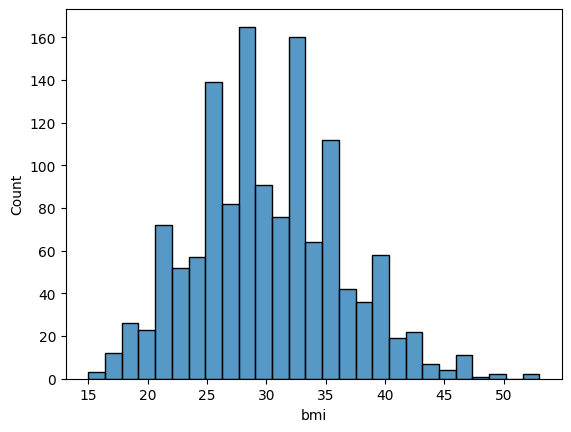

In [1208]:
sns.histplot(df_cleaned['bmi'])

In [1209]:
df_cleaned['bmi_category']=pd.cut(df_cleaned['bmi'],bins=[0,18.5,25,30,np.inf],labels=['Underweight','Normal','Overweight','Obese'] )

In [1210]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,Overweight
1334,18,1,31,0,0,2205,1,0,0,0,Obese
1335,18,1,36,0,0,1629,0,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,0,1,Normal


In [1211]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=False)

In [1212]:
df_cleaned=df_cleaned.astype(int)  


In [1213]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


In [1214]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [1215]:
select=df.select_dtypes(include=np.number).columns.tolist()
select

['age', 'bmi', 'children', 'charges']

In [1216]:
select.remove('charges')    

In [1217]:
select

['age', 'bmi', 'children']

In [1218]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_cleaned[select]=scaler.fit_transform(df_cleaned[select])  

In [1219]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,0,1,0,0,1,0
1,-1.509965,0,0.462657,-0.078767,0,1725,0,0,1,0,0,0,0,1
2,-0.797954,0,0.462657,1.580926,0,4449,0,0,1,0,0,0,0,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,1,0,0,0,1,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,1,0,0,0,0,1,0


In [1220]:
df_cleaned.dtypes

age                         float64
is_female                     int64
bmi                         float64
children                    float64
is_smoker                     int64
charges                       int64
region_northeast              int64
region_northwest              int64
region_southeast              int64
region_southwest              int64
bmi_category_Underweight      int64
bmi_category_Normal           int64
bmi_category_Overweight       int64
bmi_category_Obese            int64
dtype: object

In [1221]:
# Calculate correlation matrix and isolate 'charges'
charges_corr = df_cleaned.corr()['charges'].sort_values(ascending=False)

# Display the results
print(charges_corr)

charges                     1.000000
is_smoker                   0.787251
age                         0.299009
bmi                         0.196188
bmi_category_Obese          0.190052
region_southeast            0.073981
children                    0.067999
region_northeast            0.006350
region_northwest           -0.039905
region_southwest           -0.043210
bmi_category_Underweight   -0.050484
is_female                  -0.057293
bmi_category_Overweight    -0.082547
bmi_category_Normal        -0.121151
Name: charges, dtype: float64


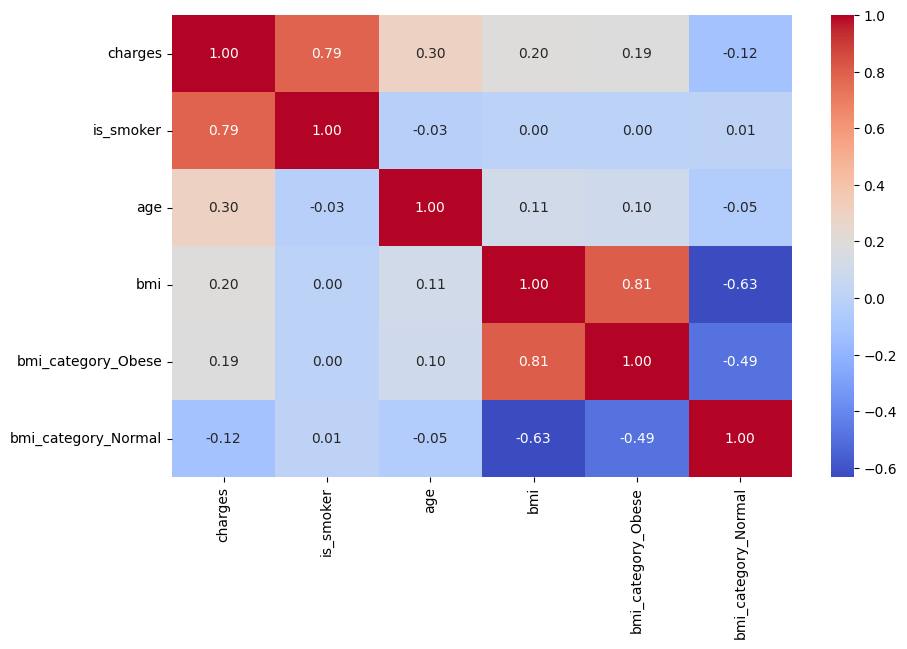

In [1222]:
top_features = charges_corr[abs(charges_corr) > 0.1].index

# Plot a heatmap of just the highly correlated features
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [1223]:
import pandas as pd
import scipy.stats as stats

# 1. Define significance threshold
ALPHA = 0.05

# 2. Bin 'charges' into 4 categories (Quartiles)
df_cleaned['charges_binned'] = pd.qcut(df_cleaned['charges'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# 3. Explicitly list all 10 categorical columns you want evaluated
categorical_columns = [
    'is_female', 
    'is_smoker', 
    'region_northeast', 
    'region_northwest', 
    'region_southeast', 
    'region_southwest',
    'bmi_category_Underweight', 
    'bmi_category_Normal', 
    'bmi_category_Overweight', 
    'bmi_category_Obese'
]

results = []
for col in categorical_columns:
    if col in df_cleaned.columns:
        # Generate the cross-tabulation matrix
        contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['charges_binned'])
        
        # Run the Chi-Square test
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
        
        # Format hypothesis conclusion
        action = "Reject H0 (Keep Feature)" if p < ALPHA else "Accept H0 (Drop Feature)"
        
        results.append({
            'Feature Column': col,
            'Chi2 Stat': round(chi2, 2),
            'p-value': f"{p:.4e}" if p < 0.0001 else round(p, 4),
            'Alpha': ALPHA,
            'Hypothesis Action': action
        })
    else:
        # Fallback note if a column is missing from your dataframe (e.g. dropped due to drop_first=True)
        results.append({
            'Feature Column': col,
            'Chi2 Stat': 'N/A',
            'p-value': 'Column Not Found',
            'Alpha': ALPHA,
            'Hypothesis Action': 'Missing from DF'
        })

# 4. Turn into a DataFrame and sort by statistical impact strength
chi2_summary_table = pd.DataFrame(results).sort_values(by='Chi2 Stat', ascending=False, key=lambda x: pd.to_numeric(x, errors='coerce'))

# 5. Display the complete clean table
print(chi2_summary_table.to_string(index=False))

          Feature Column  Chi2 Stat     p-value  Alpha        Hypothesis Action
               is_smoker     854.02 8.3183e-185   0.05 Reject H0 (Keep Feature)
        region_southeast      15.21      0.0016   0.05 Reject H0 (Keep Feature)
      bmi_category_Obese      10.26      0.0164   0.05 Reject H0 (Keep Feature)
               is_female       9.53       0.023   0.05 Reject H0 (Keep Feature)
        region_northeast       5.94      0.1143   0.05 Accept H0 (Drop Feature)
        region_southwest       5.53      0.1368   0.05 Accept H0 (Drop Feature)
 bmi_category_Overweight       4.80      0.1869   0.05 Accept H0 (Drop Feature)
     bmi_category_Normal       4.63      0.2009   0.05 Accept H0 (Drop Feature)
bmi_category_Underweight       3.39      0.3353   0.05 Accept H0 (Drop Feature)
        region_northwest       1.23      0.7467   0.05 Accept H0 (Drop Feature)


In [1224]:
final_df = df_cleaned[['age', 'bmi', 'children', 'is_smoker', 'is_female',
                       'region_northeast', 'bmi_category_Obese', 'charges']]

In [1225]:
final_df

,age,bmi,children,is_smoker,is_female,region_northeast,bmi_category_Obese,charges
0,-1.438764,-0.518122,-0.908614,1,1,0,0,16884
1,-1.509965,0.462657,-0.078767,0,0,0,1,1725
2,-0.797954,0.462657,1.580926,0,0,0,1,4449
3,-0.441948,-1.335438,-0.908614,0,0,0,0,21984
4,-0.513149,-0.354659,-0.908614,0,0,0,0,3866
...,...,...,...,...,...,...,...,...
1333,0.768473,-0.027733,1.580926,0,0,0,0,10600
1334,-1.509965,0.135731,-0.908614,0,1,1,1,2205
1335,-1.509965,0.953046,-0.908614,0,1,0,1,1629
1336,-1.296362,-0.845048,-0.908614,0,1,0,0,2007


In [1226]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Define the new, cleaner feature list (No regions!)
features = [
    'age', 'bmi', 'children', 'is_smoker', 'is_female', 'bmi_category_Obese'
]

X = df_cleaned[['age', 'bmi', 'children', 'is_smoker', 'is_female', 'bmi_category_Obese']]
y = df_cleaned['charges']

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model retrained successfully without region features!")

Model retrained successfully without region features!


In [1227]:
def get_clean_client_prediction(trained_model, feature_columns):
    INDIAN_MARKET_SCALING_FACTOR = 1.25 
    
    print("\n--- Domestic Insurance Premium Calculator ---")
    print("Please answer the 5 questions below:\n")
    
    # Gather inputs
    age = float(input("Enter client age: "))
    bmi = float(input("Enter client BMI (e.g., 24.5): "))
    children = int(input("Number of children/dependents: "))
    
    is_smoker_input = input("Does the client smoke? (yes/no): ").strip().lower()
    is_smoker = 1 if is_smoker_input == 'yes' else 0
    
    gender_input = input("Is the client female? (yes/no): ").strip().lower()
    is_female = 1 if gender_input == 'yes' else 0
    
    # Automatically derive the obese category flag from BMI
    bmi_category_Obese = 1 if bmi >= 30.0 else 0
    
    # Construct DataFrame to match the exact 6 features expected by the model
    input_data = pd.DataFrame([{
        'age': age,
        'bmi': bmi,
        'children': children,
        'is_smoker': is_smoker,
        'is_female': is_female,
        'bmi_category_Obese': bmi_category_Obese
    }], columns=feature_columns)
    
    # Predict and scale
    pred_usd = trained_model.predict(input_data)[0]
    pred_inr = pred_usd * INDIAN_MARKET_SCALING_FACTOR
    
    # Floor limit for baseline safety
    if pred_inr < 6000:
        pred_inr = 6000
        
    print("\n" + "="*40)
    print(f" Estimated Premium: ₹{pred_inr:,.2f} INR / year")
    print("="*40)

# Run the simplified questionnaire
get_clean_client_prediction(model, features)


--- Domestic Insurance Premium Calculator ---
Please answer the 5 questions below:


 Estimated Premium: ₹22,314.08 INR / year


In [1228]:
import os
print("Your Jupyter notebook is running in:")
print(os.getcwd())

print("\nLooking for app.py...")
if os.path.exists('app.py'):
    print("🎯 Success! app.py is in this exact folder.")
else:
    print("❌ app.py is NOT in this folder.")

Your Jupyter notebook is running in:
c:\Users\Rohit\OneDrive\Desktop\ML work

Looking for app.py...
🎯 Success! app.py is in this exact folder.
